# BBMED Production Data Challenge: OEE, downtime and data reconciliation

HSRW Datathon 2026, Kleve · Pablo De Villota & Ahmed Azzeh

This notebook reproduces the core analysis from the write-up using the
**synthetic sample data** in `sample_data/` (generated by
`src/make_sample_data.py`), which mirrors the real schema, relationships and
data-quality quirks of BBMED's actual production data. BBMED's real data is
not published in this repo.

Run `python src/make_sample_data.py` first if `sample_data/` is empty.

See `docs/data_model.md` for the entity relationships and `docs/findings.md`
for the full write-up this notebook supports.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
from analysis import (
    order_rollup, clean_orders, stoppage_org_technical_share,
    decode_stoppage_types, reconcile_mes_excel,
)

pd.set_option("display.precision", 3)
plt.rcParams["figure.figsize"] = (8, 4)

## 1. Load the data

Same shape as the real tables: one row per continuous production run
(`sample_production_periods.csv`), the stoppage state-time ledger, the
hand-kept Excel log, and the KM1 energy meter readings.

In [2]:
periods = pd.read_csv("../sample_data/sample_production_periods.csv",
                      parse_dates=["PointStart", "PointEnd"])
stoppages = pd.read_csv("../sample_data/sample_stoppages.csv")
excel_log = pd.read_csv("../sample_data/sample_excel_log.csv")
energy = pd.read_csv("../sample_data/sample_energy_readings.csv", parse_dates=["timestamp"])

print(f"{len(periods)} production periods, {periods.OrderNo.nunique()} orders, "
      f"{len(stoppages)} stoppage rows, {len(excel_log)} matched Excel rows")

721 production periods, 120 orders, 3038 stoppage rows, 36 matched Excel rows


## 2. Roll up to orders and compute OEE

`Availability = production time / usage time`, `Performance = actual rate / target rate`,
`OEE = Availability x Performance`. We drop orders that span more than one
machine/product and orders with an implausible target rate (stale master
data), the same two rules used in the write-up.

In [3]:
rollup = order_rollup(periods)
clean = clean_orders(rollup)

print(f"{len(rollup)} orders -> {len(clean)} after cleaning "
      f"({len(rollup) - len(clean)} dropped)")
clean[["availability", "performance", "oee"]].describe()

120 orders -> 116 after cleaning (4 dropped)


,availability,performance,oee
count,116.000,116.000,116.000
mean,0.440,0.944,0.414
std,0.101,0.040,0.088
min,0.150,0.815,0.142
25%,0.381,0.926,0.362
50%,0.433,0.950,0.411
75%,0.492,0.971,0.458
max,0.674,1.030,0.628


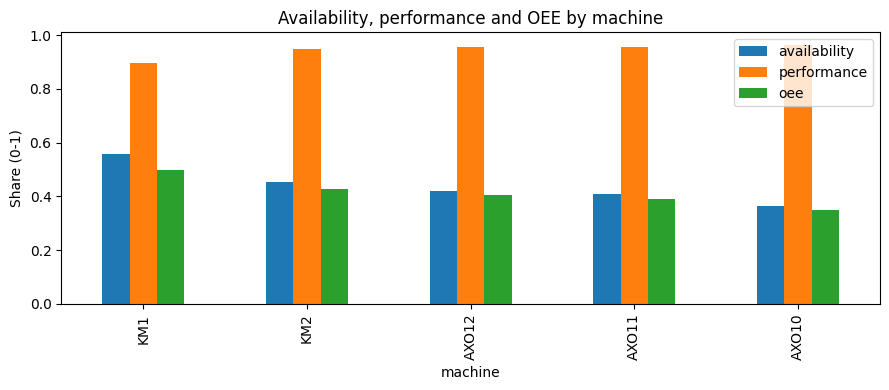

,availability,performance,oee
machine,,,
KM1,0.558,0.896,0.500
KM2,0.454,0.947,0.429
AXO12,0.421,0.957,0.404
AXO11,0.408,0.955,0.389
AXO10,0.365,0.962,0.350


In [4]:
by_machine = clean.groupby("machine")[["availability", "performance", "oee"]].mean()
by_machine = by_machine.sort_values("oee", ascending=False)
by_machine.plot(kind="bar", figsize=(9, 4), title="Availability, performance and OEE by machine")
plt.ylabel("Share (0-1)")
plt.tight_layout()
plt.show()
by_machine

**What to look for:** performance should sit in a narrow, high band across
every machine, while availability varies a lot more. That gap is the finding:
OEE is lost mostly to downtime, not to running slower.

## 3. Order size and OEE

Split orders into quartiles by units produced and compare OEE. In the real
data this showed +17.6 percentage points between the smallest and largest
quarter of orders, almost entirely through availability.

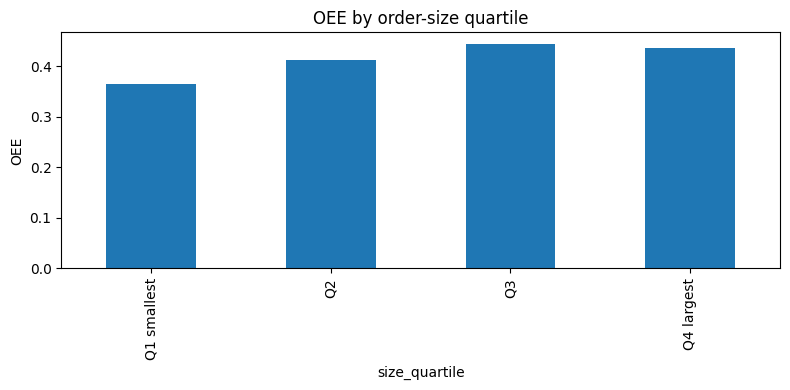

,availability,performance,oee
size_quartile,,,
Q1 smallest,0.387,0.943,0.364
Q2,0.438,0.945,0.412
Q3,0.466,0.957,0.445
Q4 largest,0.471,0.931,0.436


In [5]:
clean["size_quartile"] = pd.qcut(clean.units, 4, labels=["Q1 smallest", "Q2", "Q3", "Q4 largest"])
by_size = clean.groupby("size_quartile", observed=True)[["availability", "performance", "oee"]].mean()
by_size.plot(kind="bar", y="oee", legend=False, title="OEE by order-size quartile")
plt.ylabel("OEE")
plt.tight_layout()
plt.show()
by_size

## 4. Why lines stop: organisational vs technical downtime

Using the pre-aggregated `StoppageTimeOrganiz` / `StoppageTimeTechnic` fields
on the period table (robust to the stoppage-log quirk decoded in the next
section).

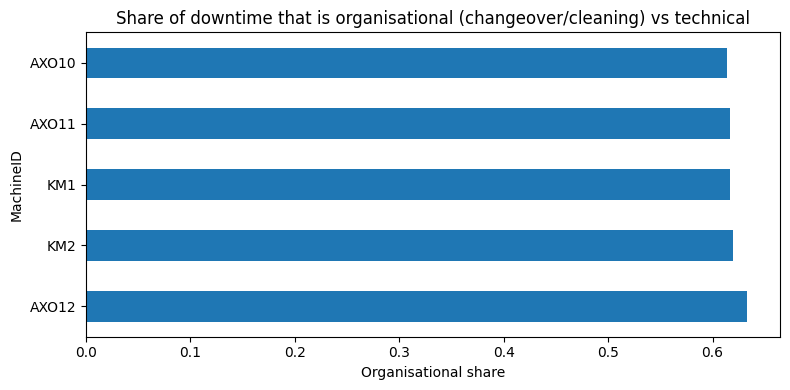

,org,tech,org_share
MachineID,,,
AXO12,165569,96037,0.633
KM2,174237,106965,0.620
KM1,120818,75031,0.617
AXO11,187557,116827,0.616
AXO10,169220,106644,0.613


In [6]:
share = stoppage_org_technical_share(periods)
share[["org_share"]].plot(kind="barh", legend=False,
                           title="Share of downtime that is organisational (changeover/cleaning) vs technical")
plt.xlabel("Organisational share")
plt.tight_layout()
plt.show()
share

## 5. Decoding the stoppage table

At the datathon, `mes_stoppages` looked broken: undefined type codes and
summed durations far exceeding a period's elapsed time. Tested against the
period table afterwards, it turns out to be a **state-time ledger**:

| Type | Meaning | Test |
|---|---|---|
| 3 | Producing | Equals `CalcProductionTime` |
| 1 | Classified stop | Reason-coded (`StoppageNo`) |
| 0 | Unclassified micro-stop | Short, no reason given |
| 2 | Idle before the period started | Matches the gap since the previous run |

The cell below tests the type-3 hypothesis directly: it should equal each
period's own `CalcProductionTime` almost exactly.

In [7]:
decoded = decode_stoppage_types(periods, stoppages)
match_rate = decoded.get("type3_matches_prod_time")
if match_rate is not None:
    print(f"Type 3 == CalcProductionTime for {match_rate.mean():.1%} of work records")
decoded.head()

Type 3 == CalcProductionTime for 100.0% of work records


,CalcUsageTime,CalcProductionTime,type_0,type_1,type_2,type_3,type3_matches_prod_time
WorkRecordID,,,,,,,
10000,2220,963,0,1257,110432,963,True
10001,5008,2172,19,2836,0,2172,True
10002,3588,1556,0,2032,0,1556,True
10003,5163,2240,0,2923,172011,2240,True
10004,2648,1022,206,1626,0,1022,True


## 6. MES vs Excel: do the two systems agree?

Compare total quantity per order between MES and the hand-kept Excel log.
**Report the median, not the mean.** A small number of mismatches (record
splitting, re-issued order numbers) can drag the mean far from what a
typical order actually looks like.

n = 36 orders matched in both sources
median abs % diff: 2.60%
mean abs % diff:   19.35%  (inflated by outliers)


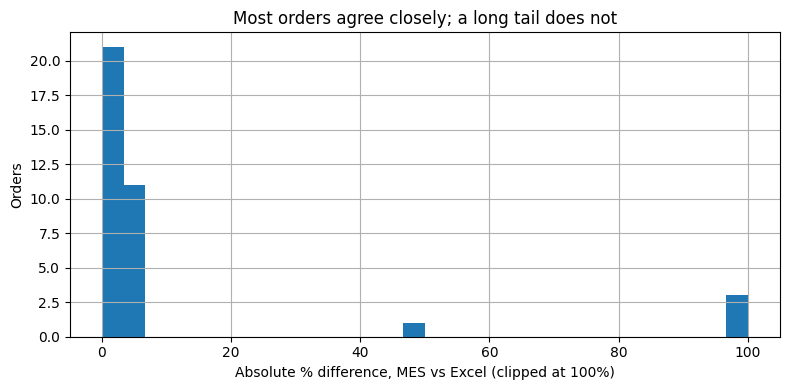

In [8]:
recon = reconcile_mes_excel(rollup, excel_log)
print(f"n = {len(recon)} orders matched in both sources")
print(f"median abs % diff: {recon.pct_diff.abs().median():.2f}%")
print(f"mean abs % diff:   {recon.pct_diff.abs().mean():.2f}%  (inflated by outliers)")

recon.pct_diff.abs().clip(upper=100).hist(bins=30)
plt.xlabel("Absolute % difference, MES vs Excel (clipped at 100%)")
plt.ylabel("Orders")
plt.title("Most orders agree closely; a long tail does not")
plt.tight_layout()
plt.show()

## 7. Energy on KM1: sub-machine draw

Five meters, one per KM1 sub-machine. Even on this short synthetic window
you can see the same shape as the real data: two sub-machines dominate the
line's total draw.

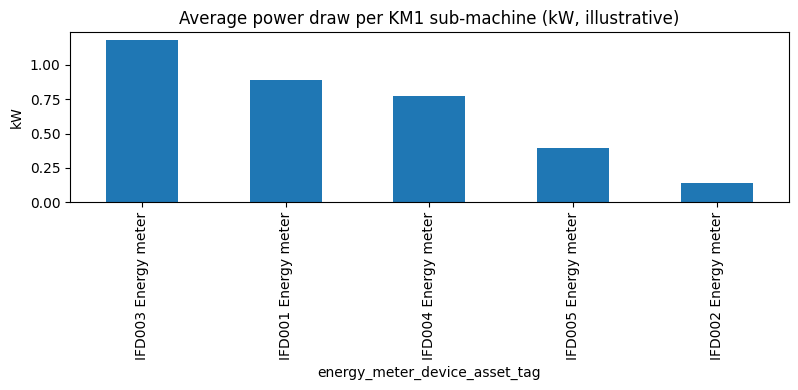

energy_meter_device_asset_tag
IFD003 Energy meter    1.177
IFD001 Energy meter    0.891
IFD004 Energy meter    0.774
IFD005 Energy meter    0.394
IFD002 Energy meter    0.138
Name: kwh_rate, dtype: float64

In [9]:
energy["kwh_rate"] = energy.groupby("energy_meter_device_asset_tag")["total_energy_passed"].diff()
avg_draw = (energy.groupby("energy_meter_device_asset_tag")["kwh_rate"].mean() * 60).sort_values(ascending=False)
avg_draw.plot(kind="bar", title="Average power draw per KM1 sub-machine (kW, illustrative)")
plt.ylabel("kW")
plt.tight_layout()
plt.show()
avg_draw

## Next steps

- Run this notebook against the real BBMED extracts (not included here) to
  reproduce the exact figures in `docs/findings.md`.
- Extend `decode_stoppage_types` into a full reason-level energy attribution
  once continuous energy logging covers all lines.
- See `docs/findings.md` for the full discussion, limitations and
  recommendations.